In [3]:
import pandas as pd
import numpy as np
import cufflinks as cf
import plotly.offline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

df = pd.read_csv('D:\SpringBoard\CreditPathAI\data\Loan_default.csv')

df.info()

<>:10: SyntaxWarning:

invalid escape sequence '\S'

<>:10: SyntaxWarning:

invalid escape sequence '\S'

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19212\2160504225.py:10: SyntaxWarning:

invalid escape sequence '\S'



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:

df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [7]:

df.head(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


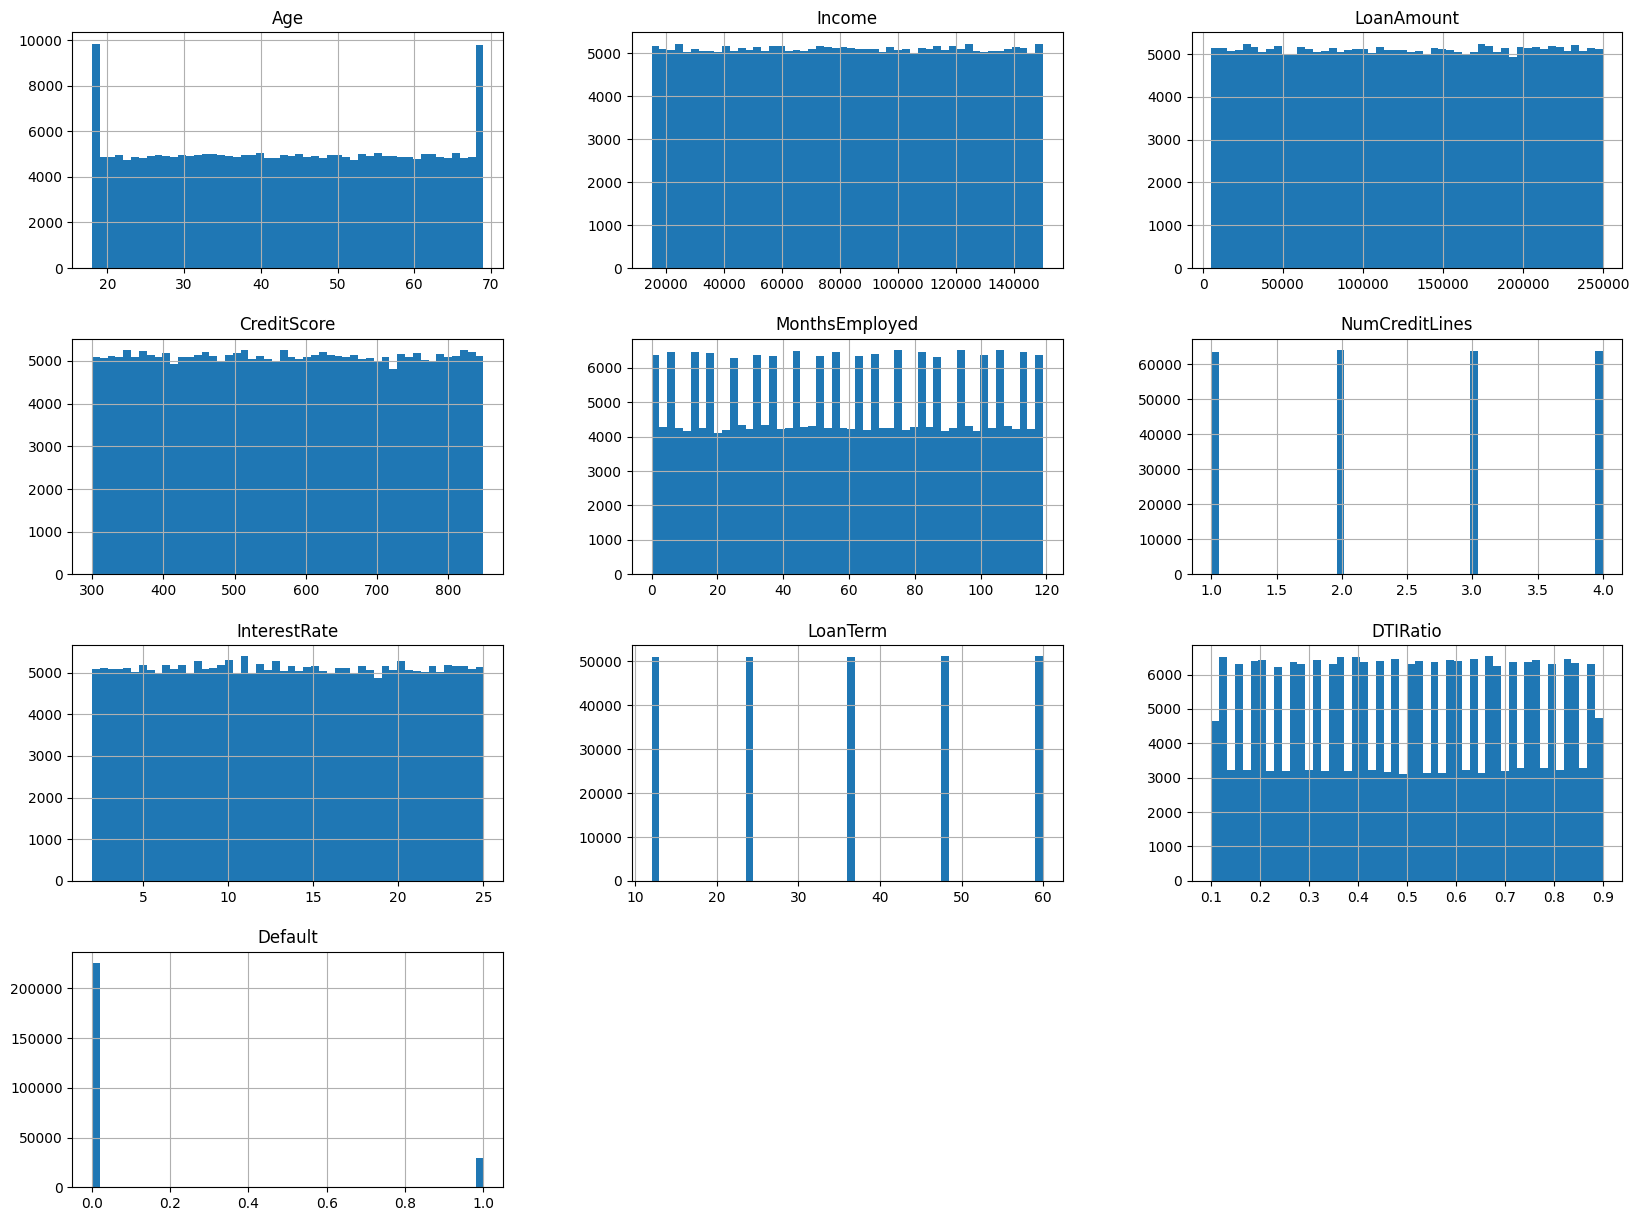

In [8]:
# Numerical data histogram to show the distribution  balance of data and ranges
df.hist(bins = 50, figsize = (20, 15))
plt.show()

In [9]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

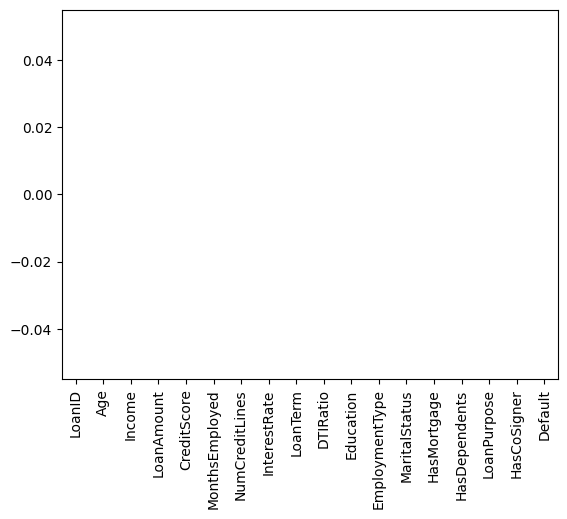

In [10]:
df.isna().sum().plot.bar()
plt.show()

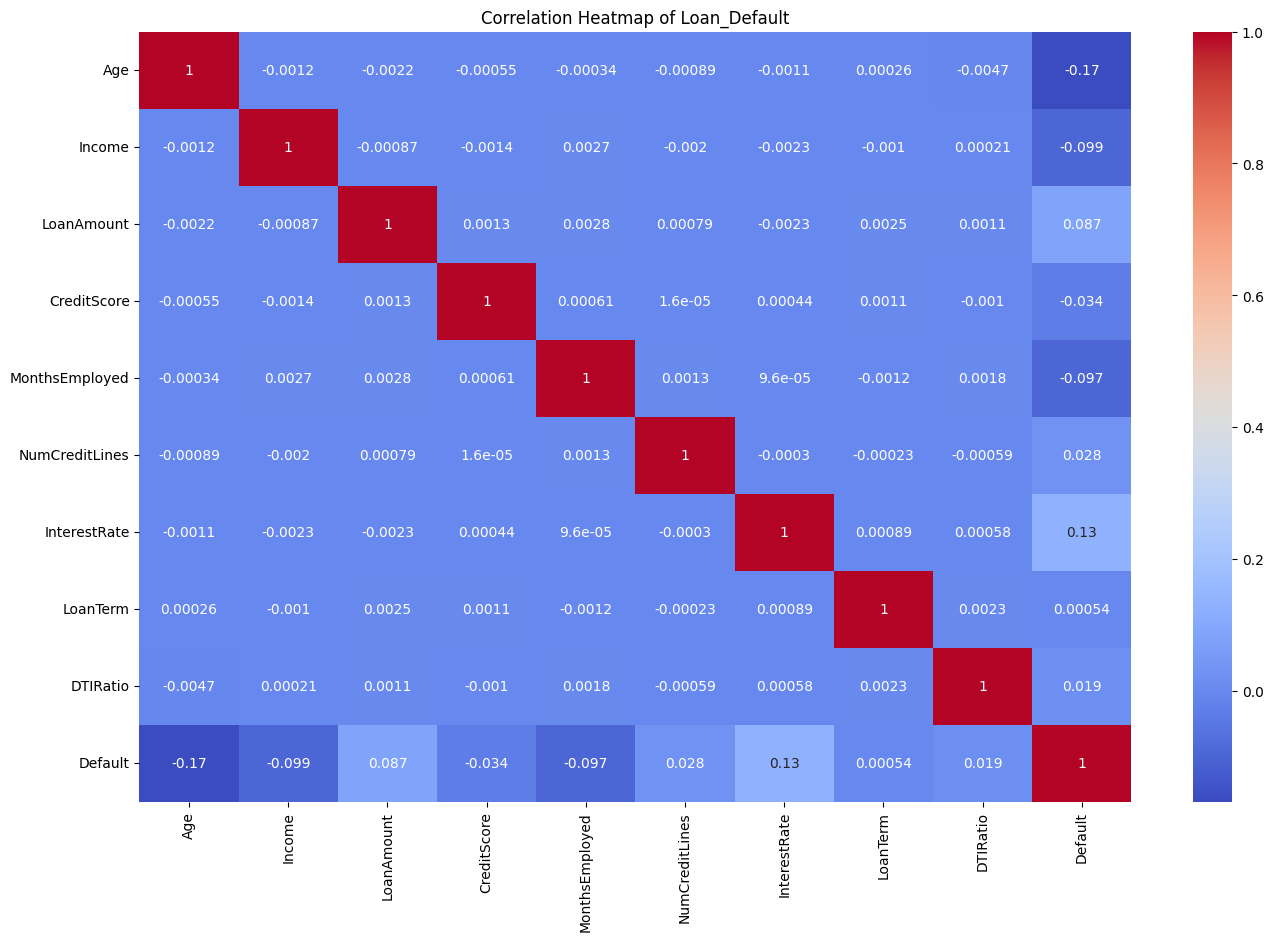

In [11]:
#heat map for the numerical columns

numerical_cols = df.select_dtypes(include=['number'])

correlation_matrix = numerical_cols.corr()


plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Loan_Default')
plt.show()

In [13]:
#null values numerical
for i in df.columns:
    print(i ,":" ,df[i].unique())


LoanID : ['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']
Age : [56 69 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 66 44
 59 45 33 64 68 54 24 26 35 21 31 67 43 37 52 34 23 51 27 48 65 62 58 18
 22 30 49 63]
Income : [ 85994  50432  84208 ... 104108  76558 124446]
LoanAmount : [ 50587 124440 129188 ... 105905 168231 208294]
CreditScore : [520 458 451 743 633 720 429 531 827 480 652 375 829 395 635 432 313 811
 319 376 419 583 528 468 839 343 514 462 580 604 551 840 787 607 669 506
 540 695 707 386 747 400 639 795 498 560 505 393 369 439 634 657 417 455
 351 655 737 771 775 680 694 534 529 416 318 411 802 305 674 585 750 303
 487 730 579 658 683 574 421 719 692 542 453 618 659 371 517 701 361 578
 656 553 734 346 584 481 447 691 457 616 564 315 436 533 372 394 834 339
 415 668 748 715 479 696 751 842 769 577 602 497 714 396 513 522 335 601
 499 380 640 566 627 786 524 449 489 401 666 818 841 406 508 749 620 536
 592 541 316 609 705 424

Age                  Axes(0.125,0.747241;0.227941x0.132759)
Income            Axes(0.398529,0.747241;0.227941x0.132759)
LoanAmount        Axes(0.672059,0.747241;0.227941x0.132759)
CreditScore          Axes(0.125,0.587931;0.227941x0.132759)
MonthsEmployed    Axes(0.398529,0.587931;0.227941x0.132759)
NumCreditLines    Axes(0.672059,0.587931;0.227941x0.132759)
InterestRate         Axes(0.125,0.428621;0.227941x0.132759)
LoanTerm          Axes(0.398529,0.428621;0.227941x0.132759)
DTIRatio          Axes(0.672059,0.428621;0.227941x0.132759)
Default               Axes(0.125,0.26931;0.227941x0.132759)
dtype: object

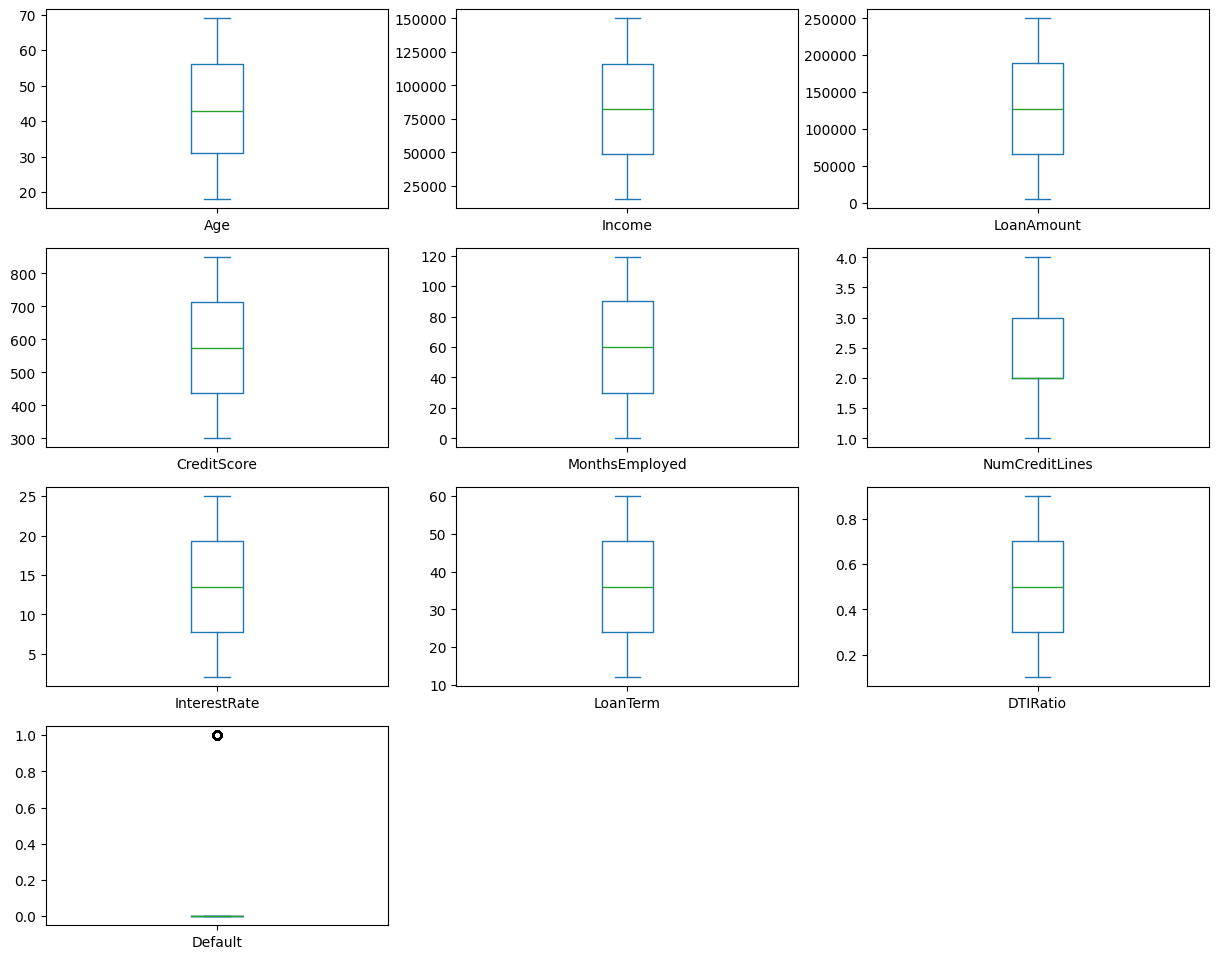

In [14]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,15))

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3500\508045448.py:6: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('D:\SpringBoard\CreditPathAI\data\Loan_default.csv')


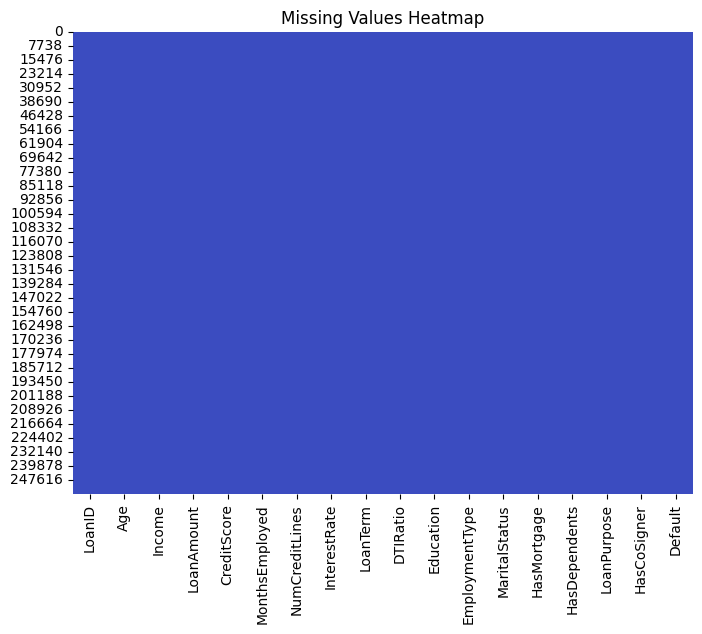

Columns in dataset: Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3500\508045448.py:6: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('D:\SpringBoard\CreditPathAI\data\Loan_default.csv')


KeyError: "['Loan_Default'] not found in axis"

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (change path/filename to your dataset)
df = pd.read_csv('D:\SpringBoard\CreditPathAI\data\Loan_default.csv')

plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

from sklearn.model_selection import train_test_split

# Check column names
print("Columns in dataset:", df.columns)

# Replace with your actual target column
X = df.drop("Loan_Default", axis=1)   # 👈 change name here
y = df["Loan_Default"]                # 👈 and here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(8,6))
sns.heatmap(X_train.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap (Training Set)")
plt.show()

